# Earthquake cycle on a non-planar fault

The forward model that connects mountain building to the earthquake cycle, built from
scratch. Three ingredients:

1. **Edge dislocations under a free surface** (Freund & Barnett 1976; Segall 2010, ch. 3)
   — the elastic fields of slipping fault segments.
2. **Axial surfaces treated as dislocations** (Souter & Hager 1997) — how a fault-bend
   fold (Suppe 1983) deforms an elastic half-space.
3. **A balanced earthquake cycle** — coseismic and interseismic deformation sum to the
   long-term motion, so

$$v_\mathrm{interseismic} \;=\; v_\mathrm{long\text{-}term} \;-\; v_\mathrm{coseismic}.$$

Everything below tracks the **uplift** field $v_z$, the quantity river profiles record.
The end point is the same smooth listric thrust discretized with 1, 10, and 100 axial
surfaces, converging to the smooth non-planar limit. Only `numpy` and `matplotlib`;
runtime a few seconds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

C_LT, C_CO, C_INT = "black", "#c62828", "#1f5fb4"   # long-term / coseismic / interseismic

## 1. The elastic building block

Vertical surface displacement of a two-dimensional edge dislocation in an elastic
half-space: uniform slip $s$ on a half-plane running down-dip from a tip at
$(x_t, -d)$, dipping $\delta$ toward $+x$ (Segall 2010, eq. 3.70; equivalent to Freund &
Barnett 1976, eq. 11):

$$u_z = -\frac{s}{\pi}\left[\sin\delta\,\tan^{-1}\zeta \;+\; \frac{\cos\delta+\zeta\sin\delta}{1+\zeta^{2}}\right],
\qquad
\zeta = \frac{x-x_t}{d}.$$

$s>0$ is normal-sense slip (hanging wall moves down-dip); a thrust is $s<0$. Two
properties matter. First, the free surface is built in: this is a half-space solution
and the surface $z=0$ carries exactly zero traction — using a full-space (image-free)
dislocation field here would be wrong. Second, no elastic moduli appear: free-surface
displacements of a 2-D dislocation depend on geometry alone. A fault segment with
uniform slip is two edge dislocations of opposite sign, one at each end.

In [2]:
def edge(x, s, delta, d, x_tip, orient=1.0):
    """Uplift of a 2D edge dislocation in a half-space: slip s on the half-plane
    running down-dip from the tip at (x_tip, -d), dipping delta toward +x
    (orient=+1) or -x (orient=-1).  s > 0 = normal sense, s < 0 = thrust.
    Segall (2010) eq. 3.70."""
    zeta = orient * (np.asarray(x, float) - x_tip) / max(d, 1e-9)
    return -(s / np.pi) * (np.sin(delta) * np.arctan(zeta)
                           + (np.cos(delta) + zeta * np.sin(delta)) / (1 + zeta**2))


def segment(x, x1, z1, x2, z2, s):
    """Uplift from uniform slip s on the fault segment (x1,z1)-(x2,z2): the edge
    dislocation at the shallow end minus the one at the deep end."""
    (xt, zt), (xb, zb) = ((x1, z1), (x2, z2)) if -z1 <= -z2 else ((x2, z2), (x1, z1))
    dx, dz = xb - xt, zb - zt
    delta = np.arctan2(-dz, abs(dx))
    orient = 1.0 if dx >= 0 else -1.0
    return edge(x, s, delta, -zt, xt, orient) + edge(x, -s, delta, -zb, xb, orient)

Before trusting the closed form, check it against direct numerical quadrature of
Volterra's formula with the free-surface (Melan) Green's functions — Segall (2010),
eq. 3.57, the integral this expression was derived from.

In [3]:
delta, d_top, W, s = np.radians(20.0), 3.0, 25.0, -1.0        # a buried thrust patch
x = np.linspace(-40.0, 40.0, 401) + 0.013
n = 10_000
eta = (np.arange(n) + 0.5) * (W / n)                          # down-dip coordinate
xi1, xi2 = 5.0 + eta * np.cos(delta), -d_top - eta * np.sin(delta)
t1 = x[:, None] - xi1
r4 = (t1**2 + xi2**2) ** 2
s2, c2 = np.sin(2 * delta), np.cos(2 * delta)
uz_quad = (s / np.pi) * np.sum((s2 * (xi2**3 - t1**2 * xi2)
                                + 2 * c2 * t1 * xi2**2) / r4, 1) * W / n
uz_closed = segment(x, 5.0, -d_top, 5.0 + W * np.cos(delta), -d_top - W * np.sin(delta), s)
print(f"closed form vs quadrature of Volterra's formula: "
      f"max diff = {abs(uz_quad - uz_closed).max():.1e}")

closed form vs quadrature of Volterra's formula: max diff = 1.7e-08


## 2. A planar thrust through one earthquake cycle

In elastic rebound, interseismic strain accumulates and is released coseismically, and
the two sum to the long-term motion (Reid 1910; Fitch & Scholz 1971). Here the
long-term motion is the overthrusting end member of fault-bend folding: the footwall is
fixed and the hanging wall translates up-dip, parallel to the fault, at slip rate
$\dot{s}$, so beyond the trace the surface rises at

$$v_z = \dot{s}\sin\alpha .$$

The coseismic term, written as a cycle-averaged rate, is thrust slip at $\dot{s}$ on the
patch that stays locked between earthquakes. The interseismic field is whatever is left,
$v_\mathrm{int} = v_\mathrm{LT} - v_\mathrm{co}$: uplift over the down-dip end of the
locked zone, subsidence in front of it, and smooth across the trace because the locked
patch's coseismic step cancels the step in the long-term field. For a planar fault the
long-term uplift is spatially uniform, so all the structure in the interseismic field
comes from the locking transition alone.

In [4]:
X_FAR, X_ANCHOR = 1.0e7, -1.0e4     # remote down-dip continuation; fixed-foreland reference


def anchored(x, x1, z1, x2, z2, s):
    """segment(), with the frame pinned to a point far into the foreland."""
    u = segment(np.append(x, X_ANCHOR), x1, z1, x2, z2, s)
    return u[:-1] - u[-1]


sdot, ALPHA, X_LOCK = 1.0, np.radians(10.0), 60.0
x = np.linspace(-100.0, 300.0, 801) + 0.037                   # avoid the trace exactly
zof = lambda xq: -np.tan(ALPHA) * xq                          # planar fault, trace at x=0

v_lt = np.where(x < 0, 0.0, sdot * np.sin(ALPHA))             # long-term (kinematic)
v_co = anchored(x, 0.0, 0.0, X_LOCK, zof(X_LOCK), -sdot)      # coseismic: locked patch slips
v_int = v_lt - v_co                                           # interseismic: the remainder

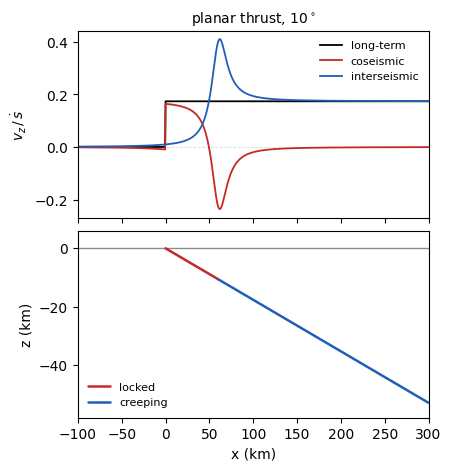

In [5]:
def geometry_panel(ax, xc, zc, x_lock, xlim, zlim, lw=1.8):
    """Fault colored by the cycle term it enters — locked (coseismic) vs
    creeping (interseismic) — beneath the free surface at z = 0."""
    ax.axhline(0.0, color="0.55", lw=1.0, zorder=1)            # free surface
    n_lock = sum(0.5 * (xc[i] + xc[i + 1]) <= x_lock for i in range(len(xc) - 1))
    ax.plot(xc[:n_lock + 1], zc[:n_lock + 1], color=C_CO, lw=lw,
            solid_capstyle="round", zorder=4, label="locked")
    ax.plot(xc[n_lock:], zc[n_lock:], color=C_INT, lw=lw,
            solid_capstyle="round", zorder=4, label="creeping")
    ax.set(xlim=xlim, ylim=zlim, xlabel="x (km)")


fig, ax = plt.subplots(2, 1, figsize=(4.4, 4.6), sharex=True, constrained_layout=True)
ax[0].axhline(0, color="0.85", lw=0.6, ls="--")
ax[0].plot(x, v_lt, color=C_LT, lw=1.3, label="long-term")
ax[0].plot(x, v_co, color=C_CO, lw=1.3, label="coseismic")
ax[0].plot(x, v_int, color=C_INT, lw=1.3, label="interseismic")
ax[0].set_ylabel(r"$v_z\,/\,\dot{s}$")
ax[0].set_title(r"planar thrust, 10$^\circ$", fontsize=10)
ax[0].legend(frameon=False, fontsize=8)

xc = np.array([0.0, X_LOCK, 300.0])
geometry_panel(ax[1], xc, zof(xc), X_LOCK, xlim=(-100, 300), zlim=(-58, 6))
ax[1].set_ylabel("z (km)")
ax[1].legend(frameon=False, fontsize=8, loc="lower left")
plt.show()

## 3. Fault bends are dislocations too

Over a non-planar thrust, slip across a change in dip folds the hanging wall. In
flexural-slip kinematics the fold is concentrated at the axial surface: the bisector of
the interlimb angle at a bend $(x_k, z_k)$, dipping
$\gamma = 90^\circ - \tfrac12(\alpha_1+\alpha_2)$ and meeting the surface at
$x_a = x_k - z_k\tan\!\big(\tfrac12(\alpha_1+\alpha_2)\big)$ (Suppe 1983; Hardy & Poblet
2005). A particle crossing it swaps velocity from one limb to the other — a velocity
jump of magnitude

$$|\mathbf{w}| = 2\dot{s}\,\sin\!\big(\tfrac{1}{2}(\alpha_1-\alpha_2)\big)$$

directed along the axial plane. A displacement jump across a plane *is* a dislocation:
the deformation-gradient field of an active axial surface is identical to that of a
fault slipping at $|\mathbf{w}|$ (Souter & Hager 1997). So the elastic model of a
non-planar fault is: every fault segment slips at $-\dot{s}$ (thrust sense) and every
bend carries a fold dislocation from the vertex up to its surface intercept, with slip
$-2\dot{s}\sin\!\big(\tfrac12(\theta_k-\theta_{k-1})\big)$, where $\theta=-\alpha$ is
the signed fault angle. Because the long-term uplift is now $\dot{s}\sin\alpha(x)$ with
$\alpha$ varying along the section, uplift localizes wherever the fault is steep.

The test fault is the circular-arc listric element of Amos et al. (2007): dip
$\theta_1$ at the trace decaying along an arc of radius $R = W_a/\sin\theta_1$ into a
flat décollement at depth $d = R(1-\cos\theta_1)$, with $W_a = 20$ km and $d = 10$ km,
and the flat continuing far down-dip so its deep tip stays remote.

In [6]:
W_A, D_FLAT = 20.0, 10.0
THETA1 = 2.0 * np.arctan(D_FLAT / W_A)              # 53.1 deg dip at the trace
R_ARC = W_A / np.sin(THETA1)


def z_listric(xq):
    xq = np.asarray(xq, float)
    z_arc = R_ARC * np.cos(THETA1) - np.sqrt(np.maximum(R_ARC**2 - (xq - W_A)**2, 0.0))
    return np.where(xq < W_A, z_arc, -D_FLAT)


def discretize(n_axial):
    """The same smooth fault as a polyline: n_axial interior vertices across
    the arc, then the flat decollement out to X_FAR."""
    xc = np.concatenate([np.linspace(0.0, W_A, n_axial + 2), [X_FAR]])
    return xc, z_listric(xc)


def axial_surfaces(xc, zc, sdot=1.0):
    """Per bend: surface intercept x_a, vertex (x_k, z_k), and fold slip
    -2 sdot sin(dtheta/2)."""
    th = np.arctan2(np.diff(zc), np.diff(xc))       # signed fault angle (<= 0)
    folds = []
    for k in range(1, len(xc) - 1):
        abar = -0.5 * (th[k - 1] + th[k])           # mean dip across the bend
        x_a = xc[k] - zc[k] * np.tan(abar)
        s_fold = -2.0 * sdot * np.sin(0.5 * (th[k] - th[k - 1]))
        folds.append((x_a, xc[k], zc[k], s_fold))
    return th, folds


def cycle_uplift(x, xc, zc, x_lock, sdot=1.0):
    """Long-term, coseismic, and interseismic uplift.  Coseismic: thrust slip on
    the fault locked up-dip of x_lock, plus every axial-surface dislocation.
    Interseismic: long-term minus coseismic."""
    th, folds = axial_surfaces(xc, zc, sdot)
    # long-term: piecewise-rigid translation in zones bounded by the intercepts
    ax_x = np.array([f[0] for f in folds])
    alpha = -th[np.searchsorted(ax_x, x)]
    v_lt = np.where(x < 0, 0.0, sdot * np.sin(alpha))
    # coseismic: locked segments + all folds, anchored to the fixed foreland
    v_co = np.zeros_like(x)
    for i in range(len(xc) - 1):
        if 0.5 * (xc[i] + xc[i + 1]) <= x_lock:
            v_co += anchored(x, xc[i], zc[i], xc[i + 1], zc[i + 1], -sdot)
    for (x_a, xk, zk, s_fold) in folds:
        v_co += anchored(x, x_a, 0.0, xk, zk, s_fold)
    return v_lt, v_co, v_lt - v_co

The acid test of the construction — and of the free-surface Green's function: with the
whole fault creeping and every fold slipping, each limb must translate as a rigid body.
The bends store no strain, so the elastic field must reproduce the kinematic fold
exactly. Passing `x_lock=inf` makes the coseismic term the full creeping-fault field, so
the remainder must vanish; what is left is the truncation of the décollement at
`X_FAR`.

In [7]:
xchk = np.linspace(-8.0, 30.0, 501) + 0.0137
xc, zc = discretize(25)
_, folds = axial_surfaces(xc, zc)
_, _, resid = cycle_uplift(xchk, xc, zc, x_lock=np.inf)     # whole fault slips
steps = np.append([f[0] for f in folds], 0.0)               # velocity-step locations
keep = np.min(np.abs(xchk[:, None] - steps[None, :]), 1) > 0.2
print(f"zero-strain residual (25 bends): {abs(resid[keep]).max():.1e} * sdot")

zero-strain residual (25 bends): 1.4e-15 * sdot


## 4. The same fault with 1, 10, and 100 axial surfaces

Coseismic (red): the fault locked up-dip of $x = 10$ km slips in the earthquake,
together with **all** axial-surface dislocations — folds are locked between earthquakes
and fold coseismically, as observed in real events (Chi-Chi 1999; Mallick et al. 2021).
Interseismic (blue): the remainder. It stays smooth because the locked folds'
concentrated steps cancel exactly against the steps in the long-term field. (The
arc–décollement junction carries one further small bend, included in the fields but not
drawn.)

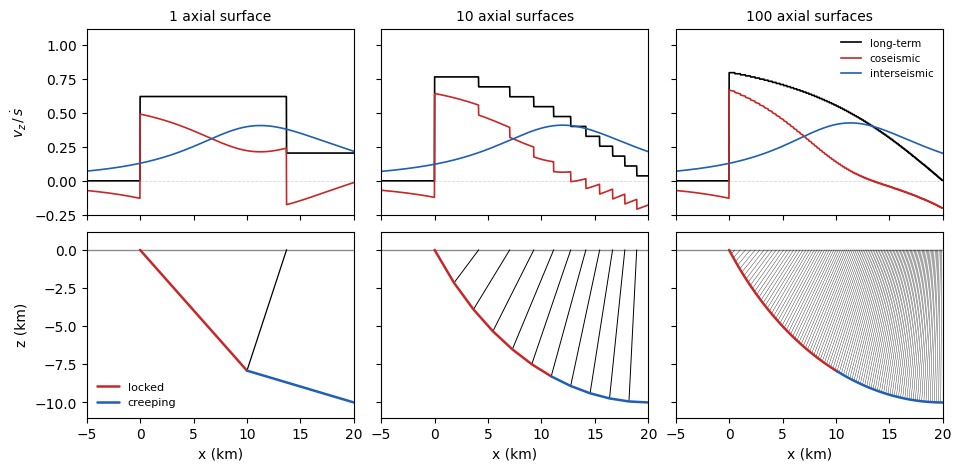

In [8]:
x = np.arange(-8.0, 30.01, 0.02) + 0.005
lw_ax = {1: 0.9, 10: 0.7, 100: 0.25}
fig, axes = plt.subplots(2, 3, figsize=(9.5, 4.6), sharex=True, sharey="row",
                         constrained_layout=True)
for c, n_ax in enumerate((1, 10, 100)):
    xc, zc = discretize(n_ax)
    _, folds = axial_surfaces(xc, zc)
    v_lt, v_co, v_int = cycle_uplift(x, xc, zc, x_lock=10.0)

    av, ag = axes[0, c], axes[1, c]
    av.axhline(0, color="0.85", lw=0.6, ls="--")
    av.plot(x, v_lt, color=C_LT, lw=1.2, label="long-term")
    av.plot(x, v_co, color=C_CO, lw=1.2, label="coseismic")
    av.plot(x, v_int, color=C_INT, lw=1.2, label="interseismic")
    av.set_ylim(-0.25, 1.12)
    av.set_title(f"{n_ax} axial surface" + ("s" if n_ax > 1 else ""), fontsize=10)

    geometry_panel(ag, xc[:-1], zc[:-1], x_lock=10.0, xlim=(-5, 20), zlim=(-11, 1.2))
    for (x_a, xk, zk, _s) in folds:
        if xk < W_A - 0.1:
            ag.plot([xk, x_a], [zk, 0.0], color="k", lw=lw_ax[n_ax], zorder=3)
    if c == 0:
        av.set_ylabel(r"$v_z\,/\,\dot{s}$")
        ag.set_ylabel("z (km)")
        ag.legend(frameon=False, fontsize=8, loc="lower left")
    if c == 2:
        av.legend(frameon=False, fontsize=7.5, loc="upper right")
plt.show()

As the bends multiply, the discrete folds merge into a continuous dislocation
distribution with density $ds_\mathrm{fold}/d\ell = \dot{s}\,\kappa(\ell)$ ($\kappa$ =
fault curvature), and all three fields converge to the smooth non-planar limit. The
long-term uplift localizes where the fault is steep, while the interseismic uplift peaks
at the down-dip end of the locked zone. When the locking transition sits on the steep
section — as on the Main Himalayan Thrust — the two maxima coincide for purely geometric
reasons, in a balanced cycle with no unreleased strain. That is the hypothesis the
accompanying paper tests by inverting Himalayan river profiles for fault geometry: see
`synthetic_test.ipynb` and `run_inversion.py`.

**References.** Freund & Barnett (1976), *BSSA* 66, 667–675 · Segall (2010),
*Earthquake and Volcano Deformation*, ch. 3 · Souter & Hager (1997), *JGR* 102,
11,931–11,942 · Suppe (1983), *Am. J. Sci.* 283, 684–721 · Hardy & Poblet (2005) ·
Amos et al. (2007), *JGR* 112 · Fitch & Scholz (1971), *JGR* 76 · Mallick et al.
(2021), *Nat. Geosci.* 14.